In [3]:
# Description: This program uses an artificial recurrent neural network called Long Short Term Memory (LSTM) to predict 
#the closing stock price of a corporation (Apple Inc.) using the past 60 day stock price.

In [2]:
#Import the libraries
import math
import pandas_datareader as web
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [3]:
#Get the stock quote 
df = web.DataReader('AAPL', data_source='yahoo', start='2016-01-01', end='2020-11-24') 
#Show the data 
df

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2015-12-31,26.757500,26.205000,26.752501,26.315001,163649200.0,24.182106
2016-01-04,26.342501,25.500000,25.652500,26.337500,270597600.0,24.202784
2016-01-05,26.462500,25.602501,26.437500,25.677500,223164000.0,23.596279
2016-01-06,25.592501,24.967501,25.139999,25.174999,273829600.0,23.134508
2016-01-07,25.032499,24.107500,24.670000,24.112499,324377600.0,22.158121
...,...,...,...,...,...,...
2020-11-18,119.820000,118.000000,118.610001,118.029999,76322100.0,118.029999
2020-11-19,119.059998,116.809998,117.589996,118.639999,74113000.0,118.639999
2020-11-20,118.769997,117.290001,118.639999,117.339996,73391400.0,117.339996


In [4]:
df['Close']

Date
2015-12-31     26.315001
2016-01-04     26.337500
2016-01-05     25.677500
2016-01-06     25.174999
2016-01-07     24.112499
                 ...    
2020-11-18    118.029999
2020-11-19    118.639999
2020-11-20    117.339996
2020-11-23    113.849998
2020-11-24    115.169998
Name: Close, Length: 1235, dtype: float64

C:\Users\himal\Anaconda3\lib\site-packages\pandas\plotting\_matplotlib\converter.py:103: FutureWarning: Using an implicitly registered datetime converter for a matplotlib plotting method. The converter was registered by pandas on import. Future versions of pandas will require you to explicitly register matplotlib converters.

To register the converters:
	>>> from pandas.plotting import register_matplotlib_converters
	>>> register_matplotlib_converters()
  warnings.warn(msg, FutureWarning)


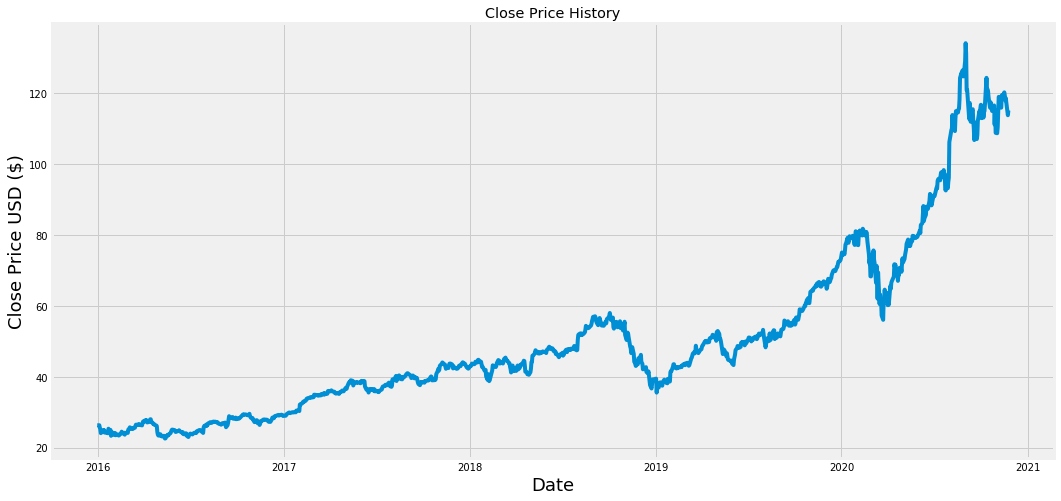

In [5]:
#Visualize the closing price history
plt.figure(figsize=(16,8))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price USD ($)',fontsize=18)
plt.show()

In [6]:
#Create a new dataframe with only the 'Close' column
data = df.filter(['Close'])
#Converting the dataframe to a numpy array
dataset = data.values
#Get /Compute the number of rows to train the model on
training_data_len = math.ceil( len(dataset) *.8) 


In [7]:
#Scale the all of the data to be values between 0 and 1 
scaler = MinMaxScaler(feature_range=(0, 1)) 
scaled_data = scaler.fit_transform(dataset)
scaled_data

array([[0.03342445],
       [0.03362607],
       [0.02771182],
       ...,
       [0.84909721],
       [0.81782342],
       [0.82965191]])

In [8]:
#Create the scaled training data set 
train_data = scaled_data[0:training_data_len  , : ]
#Split the data into x_train and y_train data sets
x_train=[]
y_train = []
for i in range(60,len(train_data)):
    x_train.append(train_data[i-60:i,0])
    y_train.append(train_data[i,0])

In [9]:
x_train

[array([0.03342445, 0.03362607, 0.02771182, 0.02320893, 0.01368789,
        0.01483042, 0.0183476 , 0.02155115, 0.01579373, 0.02056544,
        0.01521126, 0.01415836, 0.01444958, 0.01335187, 0.02482191,
        0.02038623, 0.02161836, 0.00689996, 0.00840091, 0.01568171,
        0.01364309, 0.00927463, 0.01346387, 0.01402393, 0.0082441 ,
        0.01046195, 0.01041714, 0.00880416, 0.00752722, 0.00817689,
        0.01411354, 0.01742911, 0.01326226, 0.0127694 , 0.0146512 ,
        0.00974507, 0.01290381, 0.01438238, 0.01471842, 0.01422556,
        0.02282809, 0.02332095, 0.02500113, 0.0283839 , 0.02583003,
        0.02394821, 0.02414984, 0.02426185, 0.02670372, 0.02728617,
        0.03190108, 0.03501502, 0.03463419, 0.034903  , 0.03488061,
        0.03669521, 0.03537345, 0.03434294, 0.03326764, 0.03884584]),
 array([0.03362607, 0.02771182, 0.02320893, 0.01368789, 0.01483042,
        0.0183476 , 0.02155115, 0.01579373, 0.02056544, 0.01521126,
        0.01415836, 0.01444958, 0.01335187, 0.

In [10]:
y_train

[0.04305748986171376,
 0.04178055154109403,
 0.044020795408265784,
 0.046552281916860616,
 0.043617550828506685,
 0.046193834694095076,
 0.04077244863754845,
 0.04104128405462262,
 0.04184775612243649,
 0.04502891540351564,
 0.048613302172649614,
 0.04874771133533454,
 0.04370716263419808,
 0.03839779560769177,
 0.03712085728707204,
 0.03761369658081823,
 0.03501502258258524,
 0.03436534981010089,
 0.0330212069081387,
 0.03138582136475343,
 0.016757031646794596,
 0.010058707269628264,
 0.007616832566724796,
 0.007392811598348481,
 0.010842789204797504,
 0.00862495256197468,
 0.006496710633138919,
 0.005331791342559511,
 0.005488607729593364,
 0.006899955212898018,
 0.004861342181457978,
 0.0,
 0.00040324457975907113,
 0.007930465340792503,
 0.007056771599931871,
 0.009453831854137479,
 0.008647342694619309,
 0.010932401010488896,
 0.01364309403876221,
 0.016936255258177352,
 0.020789477444385474,
 0.022559272150455667,
 0.022424845896066442,
 0.021327131186829468,
 0.018190786354448152

In [11]:
#Convert x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

In [12]:
#Reshape the data into the shape accepted by the LSTM
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

In [13]:
x_train

array([[[0.03342445],
        [0.03362607],
        [0.02771182],
        ...,
        [0.03434294],
        [0.03326764],
        [0.03884584]],

       [[0.03362607],
        [0.02771182],
        [0.02320893],
        ...,
        [0.03326764],
        [0.03884584],
        [0.04305749]],

       [[0.02771182],
        [0.02320893],
        [0.01368789],
        ...,
        [0.03884584],
        [0.04305749],
        [0.04178055]],

       ...,

       [[0.27541559],
        [0.27537077],
        [0.2774094 ],
        ...,
        [0.39435013],
        [0.38969045],
        [0.39764329]],

       [[0.27537077],
        [0.2774094 ],
        [0.28307722],
        ...,
        [0.38969045],
        [0.39764329],
        [0.39632155]],

       [[0.2774094 ],
        [0.28307722],
        [0.2985125 ],
        ...,
        [0.39764329],
        [0.39632155],
        [0.38939921]]])

In [14]:
#Build the LSTM network model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1))

In [15]:
#Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [16]:
#Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

928/928 [==============================] - 21s 23ms/step - loss: 9.0760e-04


In [17]:
#Test data set
test_data = scaled_data[training_data_len - 60: , : ]
#Create the x_test and y_test data sets
x_test = []
y_test =  dataset[training_data_len : , : ] #Get all of the rows from index 1603 to the rest and all of the columns (in this case it's only column 'Close'), so 2003 - 1603 = 400 rows of data
for i in range(60,len(test_data)):
    x_test.append(test_data[i-60:i,0])

In [18]:
#Convert x_test to a numpy array 
x_test = np.array(x_test)

In [19]:
#Reshape the data into the shape accepted by the LSTM
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))

In [20]:
#Getting the models predicted price values
predictions = model.predict(x_test) 
predictions = scaler.inverse_transform(predictions)#Undo scaling

In [21]:
#Calculate/Get the value of RMSE
rmse=np.sqrt(np.mean(((predictions- y_test)**2)))
rmse

4.8416799971552855

C:\Users\himal\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


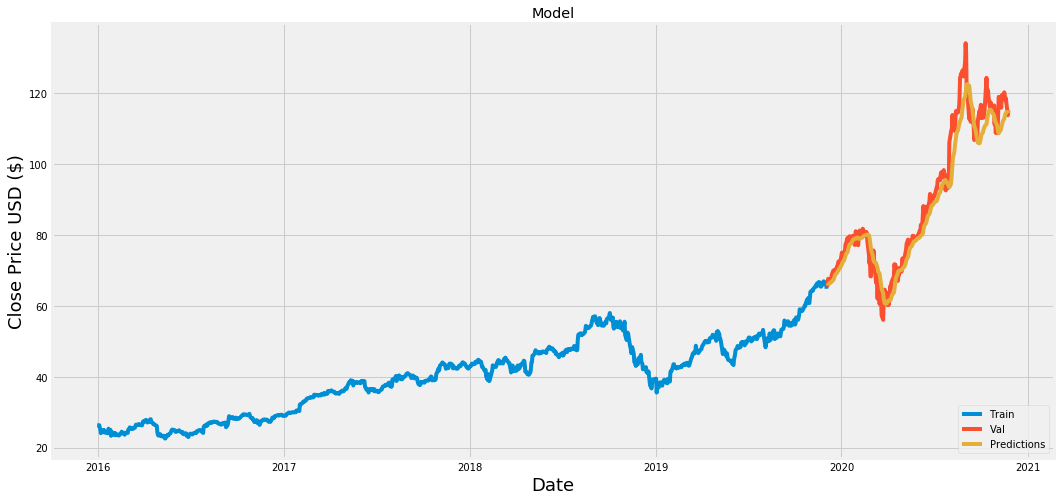

In [22]:
#Plot/Create the data for the graph
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
#Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()


In [23]:
#Show the valid and predicted prices
valid

,Close,Predictions
Date,,
2019-12-04,65.434998,66.493599
2019-12-05,66.394997,66.362907
2019-12-06,67.677498,66.300003
2019-12-09,66.730003,66.379623
2019-12-10,67.120003,66.462715
...,...,...
2020-11-18,118.029999,114.150650
2020-11-19,118.639999,114.489578
2020-11-20,117.339996,114.721672


In [24]:
#Get the quote
apple_quote = web.DataReader('AAPL', data_source='yahoo', start='2012-01-01', end='2020-11-24')
#Create a new dataframe
new_df = apple_quote.filter(['Close'])
#Get teh last 60 day closing price 
last_60_days = new_df[-60:].values
#Scale the data to be values between 0 and 1
last_60_days_scaled = scaler.transform(last_60_days)
#Create an empty list
X_test = []
#Append teh past 60 days
X_test.append(last_60_days_scaled)
#Convert the X_test data set to a numpy array
X_test = np.array(X_test)
#Reshape the data
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
#Get the predicted scaled price
pred_price = model.predict(X_test)
#undo the scaling 
pred_price = scaler.inverse_transform(pred_price)
print(pred_price)

[[113.9179]]


In [25]:
#Get the quote
apple_quote2 = web.DataReader('AAPL', data_source='yahoo', start='2020-11-25', end='2020-11-25')
print(apple_quote2['Close'])

Date
2020-11-24    115.169998
2020-11-25    116.029999
Name: Close, dtype: float64
